## Q1 A

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image_original = cv2.imread('../ghost_signal_input.png', cv2.IMREAD_UNCHANGED)

In [11]:
f_original = np.fft.fft2(image_original)
f_shifted_original = np.fft.fftshift(f_original)
magnitude_log_original = 20*np.log10(np.abs(f_original)+1)
magnitude_lin_original = np.abs(f_original)
magnitude_log_shifted_original = 20*np.log10(np.abs(f_shifted_original)+1)
magnitude_lin_shifted_original = np.abs(f_shifted_original)

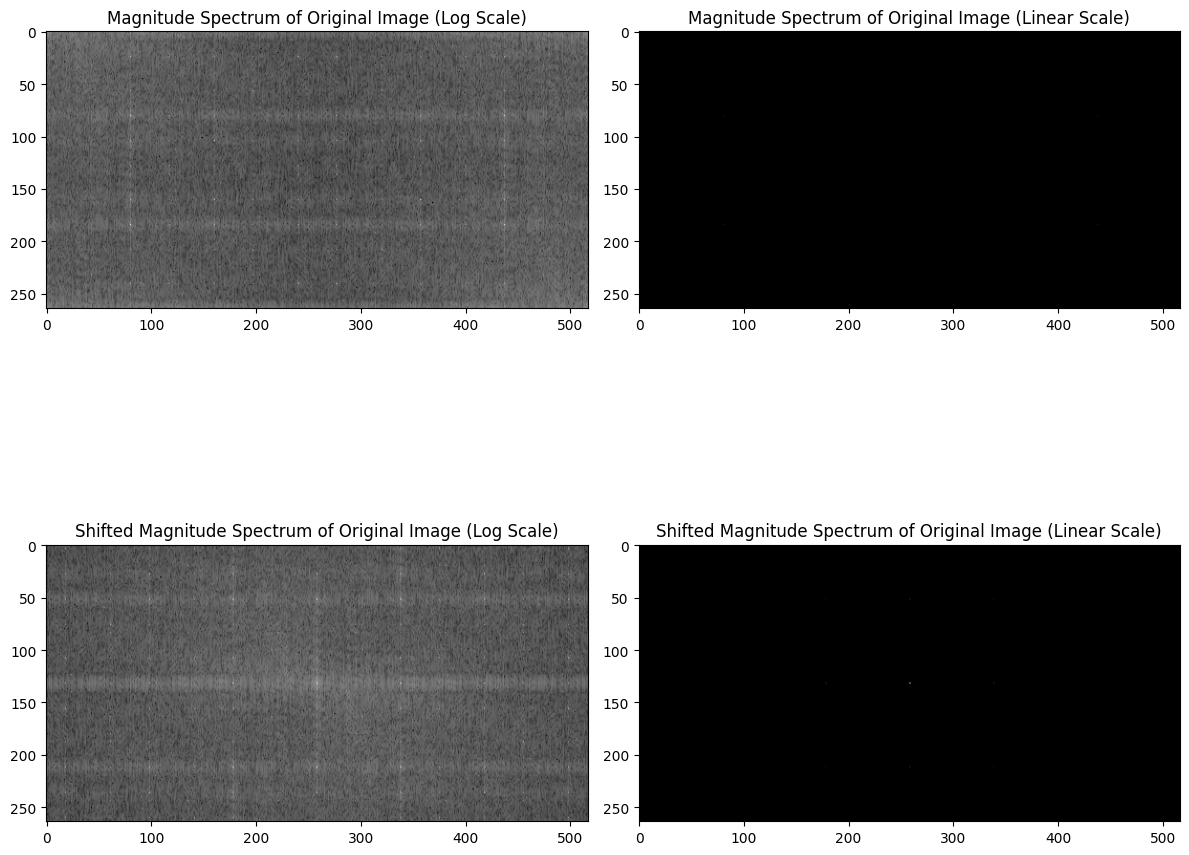

In [12]:
plt.figure(figsize=(12,12))
plt.subplot(221)
plt.imshow(magnitude_log_original, cmap='gray')
plt.title('Magnitude Spectrum of Original Image (Log Scale)')

plt.subplot(222)
plt.imshow(magnitude_lin_original, cmap='gray')
plt.title('Magnitude Spectrum of Original Image (Linear Scale)')

plt.subplot(223)
plt.imshow(magnitude_log_shifted_original, cmap='gray')
plt.title('Shifted Magnitude Spectrum of Original Image (Log Scale)')

plt.subplot(224)
plt.imshow(magnitude_lin_shifted_original, cmap='gray')
plt.title('Shifted Magnitude Spectrum of Original Image (Linear Scale)')

plt.tight_layout()
plt.axis('on')
plt.show()

In [13]:
H = np.ones_like(f_shifted_original, dtype=np.int8)
noise = [(133, 180), (133, 256), (133, 336),
    (50, 180),  (50, 256),  (50, 336),
    (214, 180), (214, 256), (214, 336)]
r = 5
for n in noise:
  row, col = n[0], n[1]
  H[row-r:row+r+1,col-r:col+r+1] = 0.0
f_shifted_filtered = f_shifted_original*H

magnitude_log_shifted_filtered = 20*np.log10(np.abs(f_shifted_filtered)+1)

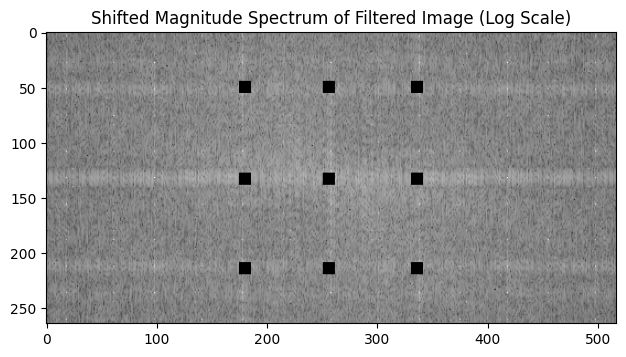

In [14]:
plt.figure(figsize=(6, 6))
plt.subplot(111)
plt.imshow(magnitude_log_shifted_filtered, cmap='gray')
plt.title('Shifted Magnitude Spectrum of Filtered Image (Log Scale)')
plt.axis('off')
plt.tight_layout()
plt.axis('on')
plt.show()

In [15]:
f_filtered = np.fft.ifftshift(f_shifted_filtered)
magnitude_log_filtered = 20*np.log10(np.abs(f_filtered)+1)
image_filtered = np.fft.ifft2(f_filtered).real

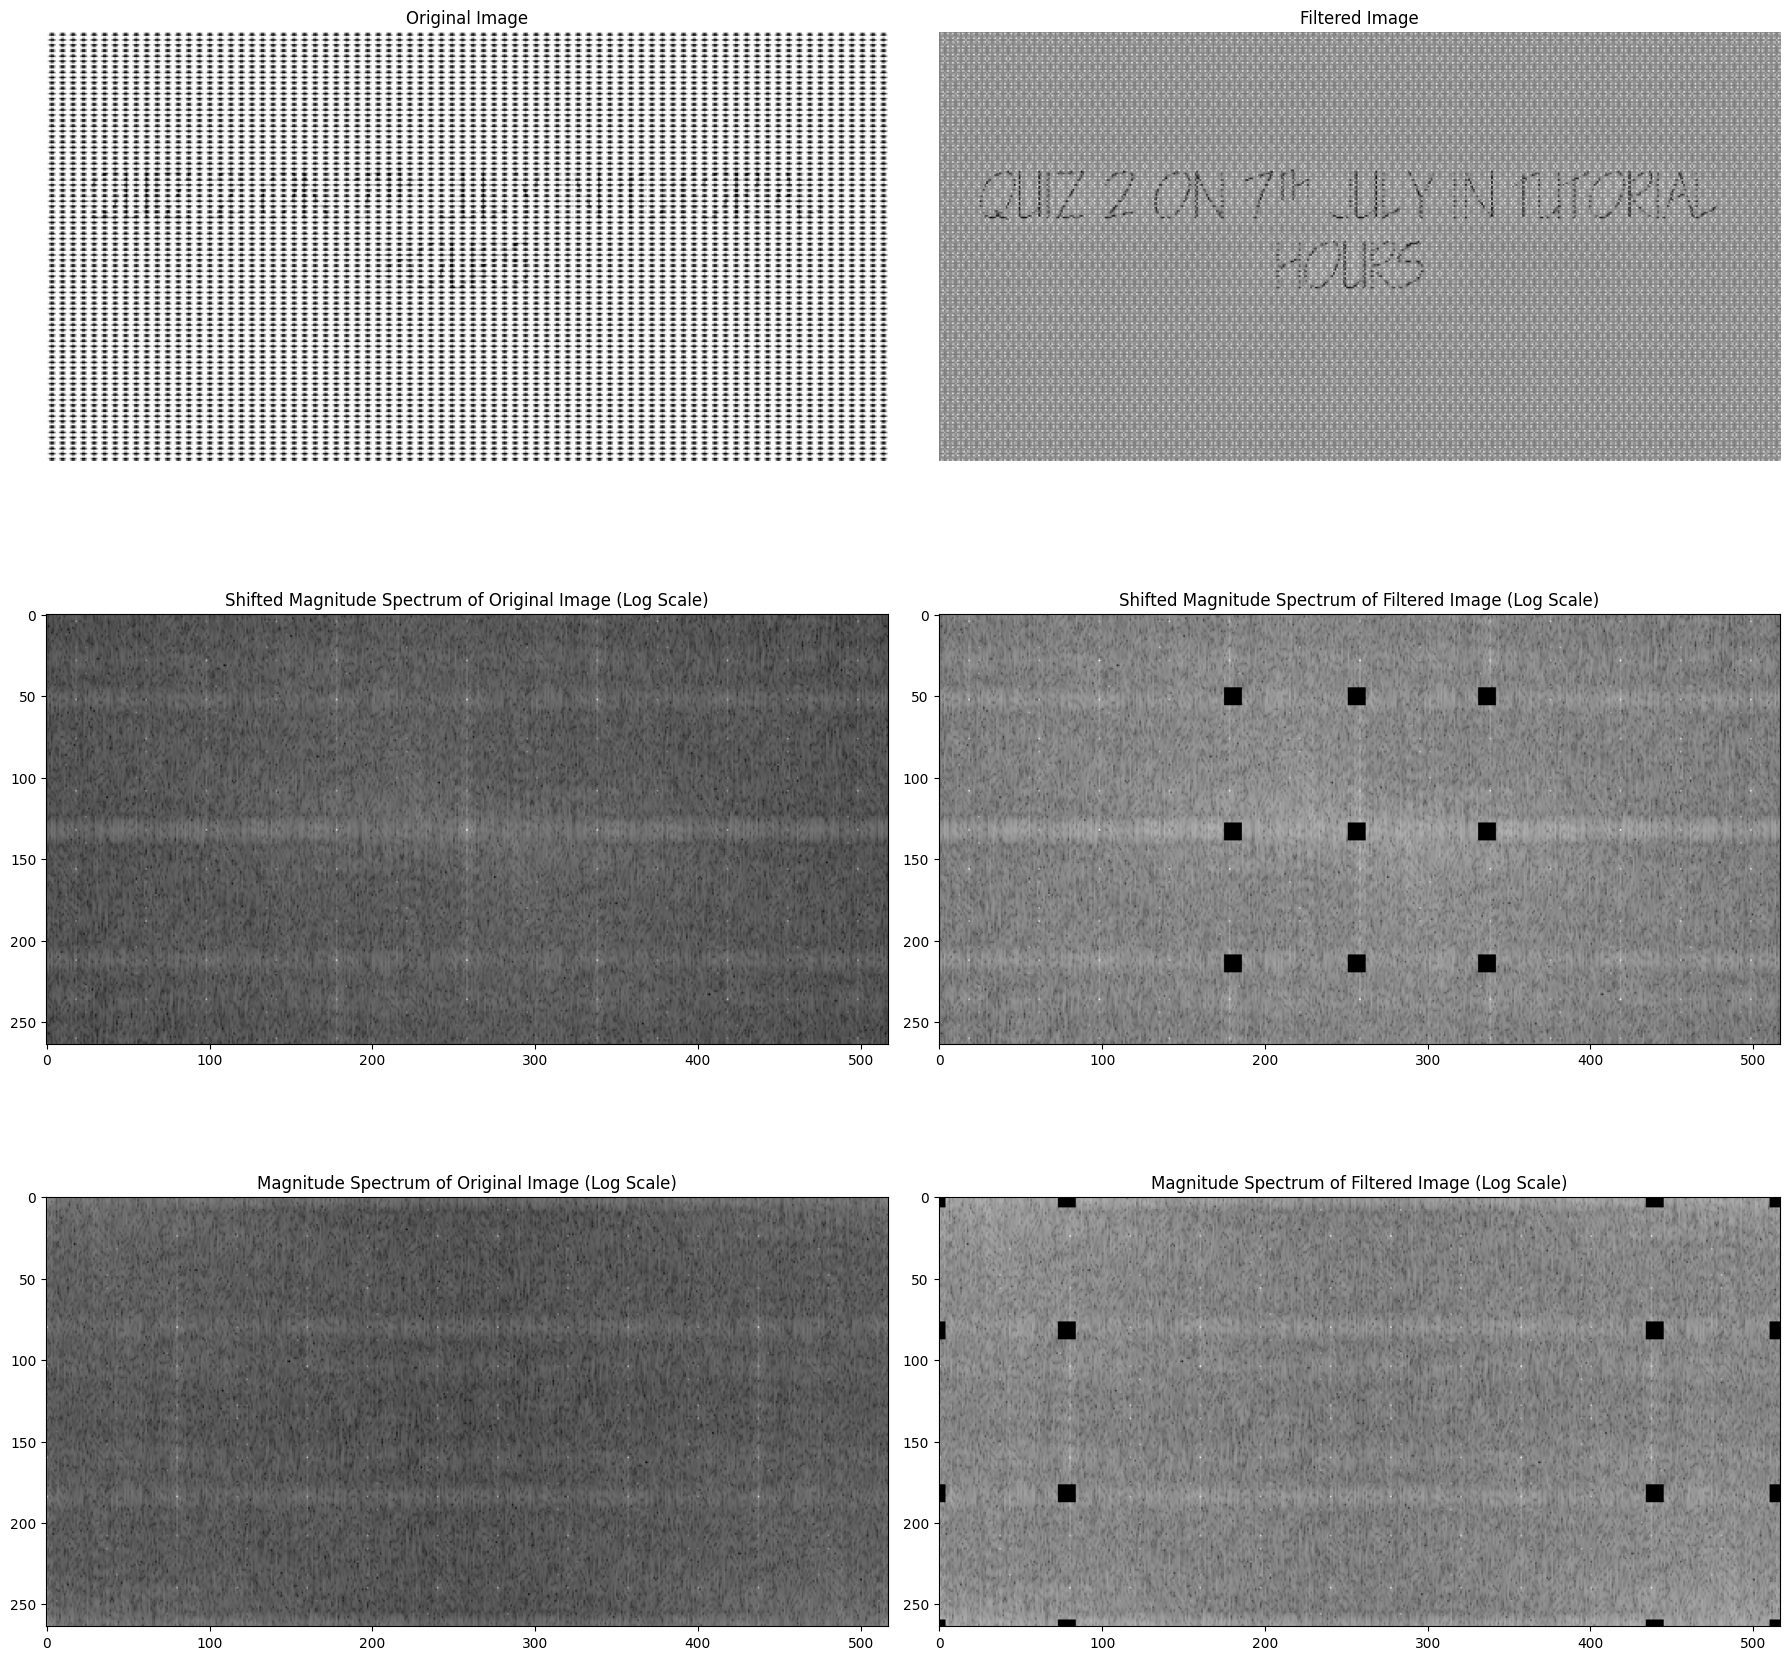

In [16]:
plt.figure(figsize=(18, 18))

plt.subplot(321)
plt.imshow(image_original, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(322)
plt.imshow(image_filtered, cmap='gray')
plt.title('Filtered Image')
plt.axis('off')

plt.subplot(323)
plt.imshow(magnitude_log_shifted_original, cmap='gray')
plt.title('Shifted Magnitude Spectrum of Original Image (Log Scale)')

plt.subplot(324)
plt.imshow(magnitude_log_shifted_filtered, cmap='gray')
plt.title('Shifted Magnitude Spectrum of Filtered Image (Log Scale)')

plt.subplot(325)
plt.imshow(magnitude_log_original, cmap='gray')
plt.title('Magnitude Spectrum of Original Image (Log Scale)')

plt.subplot(326)
plt.imshow(magnitude_log_filtered, cmap='gray')
plt.title('Magnitude Spectrum of Filtered Image (Log Scale)')

plt.tight_layout()
plt.show()

## Q1 B

In [1]:
import cv2
import numpy as np
from PIL import Image

In [ ]:
def extract_boundaries_sobel(input_path, output_path):
    try:
        pil_img = Image.open(input_path).convert('RGB')
        open_cv_image = np.array(pil_img)
        img_bgr = open_cv_image[:, :, ::-1].copy()
        gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        blurred_img = cv2.GaussianBlur(gray_img, (3, 3), 0)
    
        sobel_x = cv2.Sobel(blurred_img, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)
        sobel_y = cv2.Sobel(blurred_img, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3)
        
        abs_sobel_x = cv2.convertScaleAbs(sobel_x)
        abs_sobel_y = cv2.convertScaleAbs(sobel_y)
        sobel_magnitude = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

        _, final_edges = cv2.threshold(sobel_magnitude, 50, 255, cv2.THRESH_BINARY)
        
        cv2.imwrite(output_path, final_edges)
        print(f"SUCCESS: Regenerated boundaries saved to {output_path}")

    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
input_path = "../Q1_data/missing_boundaries_input.avif" 
output_path = "output.png"
extract_boundaries_sobel(input_path, output_path)

SUCCESS: Regenerated boundaries saved to output.png
